# Watermark Teks "sabila" pada Domain Pixel — Diuji terhadap Kompresi Neural Codec

```
Teks "sabila" -> payload 48 bit -> sisip ke nilai pixel frame -> video ber-watermark
   -> kompresi Neural Codec -> baca bit langsung dari pixel -> bandingkan dengan payload asli
   -> BER + Bit Accuracy + Status Deteksi (+ PSNR, + false positive test)
```

Hanya satu metode: **watermark pixel**. Neural Codec (CompressAI, pretrained, dibekukan) dipakai **hanya sebagai penguji kompresi**.
Tidak ada latent watermarking, Embedder, Neural Extractor, training, H.264/H.265/AV1, maupun perbandingan antar-codec.

## 1. Import library

In [1]:
import sys, subprocess, importlib.util, shutil

def pip(*pkgs, no_deps=False):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + (['--no-deps'] if no_deps else []) + list(pkgs), check=False)

# --no-deps: metadata compressai meminta numpy<2, sedangkan Colab memakai numpy 2.x
if importlib.util.find_spec('compressai') is None:
    pip('compressai==1.2.8', 'pytorch-msssim', 'einops', no_deps=True)
if importlib.util.find_spec('torch_geometric') is None:   # diimpor compressai.__init__
    pip('torch_geometric')
if shutil.which('ffmpeg') is None:
    subprocess.run('apt-get -y install ffmpeg > /dev/null 2>&1', shell=True)

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, random, tempfile
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.stats import binom

## 2. Konfigurasi

Payload = `"sabila"` -> 6 byte -> **48 bit**, disusun sebagai grid **6 x 8 blok** (1 blok = 1 bit).
Tiap blok dimodulasi pola pseudo-acak ±1 (kunci `KEY`) dengan kekuatan `STRENGTH`; bit 1 = pola ditambah, bit 0 = pola dikurangi.
Pola **berbeda di tiap frame** (kunci sama), sehingga gangguan dari isi video (host) saling meniadakan ketika dirata-ratakan antar frame.

In [16]:
DATASET_DIR = '/content/drive/MyDrive/Video_data/test'
OUTPUT_DIR  = '/content/drive/MyDrive/Video_data/output_pixel_wm'
QUICK_TEST  = False                       # True = uji alur cepat (hasil tidak representatif)

PAYLOAD_TEXT = 'sabila'
FRAME_SIZE, MAX_FRAMES, MAX_VIDEOS = (192, 256), 100, 30     # (H, W) wajib kelipatan 64
CODEC_QUALITY = 3                         # 1 = kompresi paling tinggi ... 8 = kualitas tertinggi

# --- watermark pixel ---
GRID, CELL = (6, 8), 8                    # 6x8 blok = 48 bit; tiap blok berisi sel 8x8 pixel
STRENGTH = 6                              # amplitudo (level pixel 0-255); naikkan = lebih tahan, PSNR turun
KEY = 2024                                # kunci pola (harus sama saat menyisip & membaca)

# --- keputusan deteksi ---
P_FALSE_ALARM = 1e-4                      # peluang bit cocok >= ambang hanya karena kebetulan

SEED = 42
if QUICK_TEST:
    MAX_FRAMES, MAX_VIDEOS = 16, 2

os.makedirs(f'{OUTPUT_DIR}/videos', exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## 3. Load Neural Codec (CompressAI, pretrained, dibekukan)

In [17]:
from compressai.zoo import image_models

codec = image_models['bmshj2018-hyperprior'](quality=CODEC_QUALITY, pretrained=True).to(device).eval()
for p in codec.parameters():
    p.requires_grad_(False)
codec.update(force=True)

def to_tensor(f): return torch.from_numpy(f).permute(0, 3, 1, 2).float().div(255.0)
def to_uint8(x):  return x.clamp(0, 1).mul(255.0).round().byte().permute(0, 2, 3, 1).cpu().numpy()

@torch.no_grad()
def neural_codec(frames, batch=16):
    '''Kompresi Neural Codec (bitstream nyata). Decoding hanya langkah internal untuk
    mendapatkan kembali pixel. -> (frame uint8 hasil codec, bpp rata-rata)'''
    out, nbits = [], 0
    for i in range(0, len(frames), batch):
        x = to_tensor(frames[i:i + batch]).to(device)
        enc = codec.compress(x)
        out.append(to_uint8(codec.decompress(enc['strings'], enc['shape'])['x_hat']))
        nbits += 8 * sum(len(s) for part in enc['strings'] for s in part)
    return np.concatenate(out), nbits / (len(frames) * frames.shape[1] * frames.shape[2])

def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float(10 * np.log10(255.0 ** 2 / max(mse, 1e-10)))

print(f'Neural Codec bmshj2018-hyperprior, quality={CODEC_QUALITY} siap.')

Neural Codec bmshj2018-hyperprior, quality=3 siap.


## 4. Load video

In [18]:
def read_video(path, max_frames=MAX_FRAMES, size=FRAME_SIZE):
    '''-> (frame uint8 (T,H,W,3) RGB, fps). ffmpeg hanya dipakai untuk membaca file sumber.'''
    H, W = size
    probe = subprocess.run(['ffprobe', '-v', 'error', '-select_streams', 'v:0', '-show_entries',
                            'stream=r_frame_rate', '-of', 'csv=p=0', path], capture_output=True, text=True).stdout.strip()
    try:
        a, b = probe.split('/'); fps = float(a) / float(b)
        fps = fps if 1 <= fps <= 240 else 25.0
    except Exception:
        fps = 25.0
    cmd = ['ffmpeg', '-v', 'error', '-i', path, '-vf', f'scale={W}:{H}:flags=area']
    cmd += ['-frames:v', str(max_frames)] if max_frames else []
    raw = np.frombuffer(subprocess.run(cmd + ['-f', 'rawvideo', '-pix_fmt', 'rgb24', '-'], capture_output=True).stdout, np.uint8)
    n = raw.size // (H * W * 3)
    assert n > 0, f'tidak ada frame terbaca dari {path}'
    return raw[:n * H * W * 3].reshape(n, H, W, 3).copy(), fps

def save_lossless(frames, path, fps):
    '''Simpan video ber-watermark lossless (FFV1) hanya sebagai arsip; BUKAN bagian pengujian kompresi.'''
    T, H, W, _ = frames.shape
    cmd = ['ffmpeg', '-y', '-v', 'error', '-f', 'rawvideo', '-pix_fmt', 'rgb24', '-s', f'{W}x{H}', '-r', str(fps),
           '-i', '-', '-c:v', 'ffv1', '-pix_fmt', 'gbrp', path]
    res = subprocess.run(cmd, input=np.ascontiguousarray(frames).tobytes(), capture_output=True)
    assert res.returncode == 0, res.stderr.decode(errors='ignore')[-300:]

assert FRAME_SIZE[0] % 64 == 0 and FRAME_SIZE[1] % 64 == 0
all_videos = sorted(f for f in os.listdir(DATASET_DIR)
                    if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')) and '_wm' not in f.lower())[:MAX_VIDEOS]
print(len(all_videos), 'video akan diuji')

30 video akan diuji


## 5. Ekstraksi frame

In [19]:
videos = {}      # nama -> (frame asli uint8 (T,H,W,3), fps)
for v in tqdm(all_videos, desc='Ekstraksi frame'):
    videos[v] = read_video(os.path.join(DATASET_DIR, v))
print({v: f[0].shape for v, f in list(videos.items())[:3]}, '...')

Ekstraksi frame:   0%|          | 0/30 [00:00<?, ?it/s]

{'v_CricketShot_g01_c01.avi': (84, 192, 256, 3), 'v_CricketShot_g01_c02.avi': (91, 192, 256, 3), 'v_CricketShot_g01_c03.avi': (95, 192, 256, 3)} ...


## 6. Konversi `"sabila"` menjadi payload 48 bit

In [22]:
def text_to_bits(text):
    return np.array([int(b) for ch in text.encode() for b in f'{ch:08b}'], np.int64)

def bits_to_text(bits):
    s = ''.join(str(int(b)) for b in bits)
    return bytes(int(s[i:i + 8], 2) for i in range(0, len(s), 8)).decode('utf-8', errors='replace')

def bits_str(bits):
    s = ''.join(str(int(b)) for b in bits)
    return ' '.join(s[i:i + 8] for i in range(0, len(s), 8))

PAYLOAD = text_to_bits(PAYLOAD_TEXT)
N_BITS = len(PAYLOAD)
assert N_BITS == GRID[0] * GRID[1] == 48, 'payload harus 48 bit = jumlah blok grid'
print(f'Watermark asli : "{PAYLOAD_TEXT}"')
print(f'Payload ({N_BITS} bit): {bits_str(PAYLOAD)}')

Watermark asli : "sabila"
Payload (48 bit): 01110011 01100001 01100010 01101001 01101100 01100001


## 7. Penyisipan payload ke pixel

Setiap bit dipetakan ke satu blok. Nilai pixel di blok itu diubah: `pixel' = pixel + STRENGTH * (2*bit-1) * pola(±1)`.
Pola berimbang (jumlah +1 = jumlah -1), jadi kecerahan rata-rata blok tidak berubah. Perubahan langsung pada nilai pixel; tidak ada jaringan saraf.

In [23]:
def make_patterns(n_frames, H, W, grid=GRID, cell=CELL, key=KEY):
    '''Pola pseudo-acak berimbang per frame & per bit -> (T, 48, bh, bw).'''
    R, C = grid; bh, bw = H // R, W // C
    assert H % R == 0 and W % C == 0 and bh % cell == 0 and bw % cell == 0
    ch, cw = bh // cell, bw // cell
    base = np.array([1.0] * (ch * cw // 2) + [-1.0] * (ch * cw // 2), np.float32)
    rng = np.random.RandomState(key)
    cells = np.stack([[rng.permutation(base) for _ in range(R * C)] for _ in range(n_frames)]).reshape(n_frames, R * C, ch, cw)
    return np.kron(cells, np.ones((1, 1, cell, cell), np.float32))

def embed_pixel_watermark(frames, bits=PAYLOAD, strength=STRENGTH):
    T, H, W, _ = frames.shape; R, C = GRID; bh, bw = H // R, W // C
    pats = make_patterns(T, H, W)
    sgn = (np.asarray(bits) * 2 - 1).astype(np.float32)
    delta = (sgn[None, :, None, None] * pats).reshape(T, R, C, bh, bw).transpose(0, 1, 3, 2, 4).reshape(T, H, W)
    return np.clip(np.rint(frames.astype(np.float32) + strength * delta[..., None]), 0, 255).astype(np.uint8)

## 8. Membentuk video ber-watermark

In [24]:
wm_videos = {}
for v, (frames, fps) in tqdm(videos.items(), desc='Sisip watermark'):
    wm_videos[v] = embed_pixel_watermark(frames)
    save_lossless(wm_videos[v], f'{OUTPUT_DIR}/videos/{os.path.splitext(v)[0]}_wm.mkv', fps)
print(len(wm_videos), 'video ber-watermark dibuat')

Sisip watermark:   0%|          | 0/30 [00:00<?, ?it/s]

30 video ber-watermark dibuat


## 9. Kompresi menggunakan Neural Codec

In [25]:
codec_wm, bpp_wm = {}, {}
for v, wm in tqdm(wm_videos.items(), desc='Neural Codec (ber-watermark)'):
    codec_wm[v], bpp_wm[v] = neural_codec(wm)
print(f'bpp rata-rata: {np.mean(list(bpp_wm.values())):.3f}')

Neural Codec (ber-watermark):   0%|          | 0/30 [00:00<?, ?it/s]

bpp rata-rata: 0.297


## 10. Membaca kembali watermark dari pixel

Untuk tiap blok, hitung korelasi antara nilai pixel (rata-rata kanal) dengan pola ±1 milik bit tersebut, lalu rata-ratakan antar frame.
Skor > 0 -> bit 1, skor ≤ 0 -> bit 0. Murni operasi pada nilai pixel, tanpa neural network.

In [26]:
def extract_pixel_watermark(frames):
    T, H, W, _ = frames.shape; R, C = GRID; bh, bw = H // R, W // C
    pats = make_patterns(T, H, W)
    g = frames.astype(np.float32).mean(-1)
    blocks = g.reshape(T, R, bh, C, bw).transpose(0, 1, 3, 2, 4).reshape(T, R * C, bh, bw)
    score = (blocks * pats).mean((2, 3)).mean(0)        # korelasi per bit, dirata-rata antar frame
    return (score > 0).astype(np.int64)

## 11-14. Bandingkan payload, hitung BER, Bit Accuracy, dan Status Deteksi

`MIN_MATCH` = jumlah bit cocok minimum agar peluang kebetulan ≤ `P_FALSE_ALARM` (uji binomial, p=0.5 per bit).

In [27]:
MIN_MATCH = next(k for k in range(N_BITS + 1) if binom.sf(k - 1, N_BITS, 0.5) <= P_FALSE_ALARM)
print(f'Status Deteksi = "Terdeteksi" jika bit cocok >= {MIN_MATCH}/{N_BITS} (BER <= {1 - MIN_MATCH / N_BITS:.3f}), peluang kebetulan <= {P_FALSE_ALARM}')

def evaluate(bits_read):
    n_match = int((bits_read == PAYLOAD).sum())
    return {'BER': 1 - n_match / N_BITS, 'Bit Accuracy': n_match / N_BITS, 'Bit Cocok': f'{n_match}/{N_BITS}',
            'Teks Terbaca': bits_to_text(bits_read),
            'Status Deteksi': 'Terdeteksi' if n_match >= MIN_MATCH else 'Tidak Terdeteksi'}

rows, read_bits = [], {}
for v in videos:
    read_bits[v] = extract_pixel_watermark(codec_wm[v])
    rows.append({'Video': v, **evaluate(read_bits[v]),
                 'PSNR_WM (dB)': psnr(wm_videos[v], videos[v][0]),        # perubahan akibat watermark
                 'PSNR_Codec (dB)': psnr(codec_wm[v], videos[v][0]),      # hasil Neural Codec vs asli
                 'bpp': bpp_wm[v]})
df_wm = pd.DataFrame(rows)

Status Deteksi = "Terdeteksi" jika bit cocok >= 38/48 (BER <= 0.208), peluang kebetulan <= 0.0001


## 15. False Positive Test (video TANPA watermark)

In [28]:
rows_fp = []
for v, (frames, fps) in tqdm(videos.items(), desc='False positive'):
    comp, _ = neural_codec(frames)                                   # video asli -> Neural Codec
    rows_fp.append({'Video': v, **evaluate(extract_pixel_watermark(comp))})
df_fp = pd.DataFrame(rows_fp)
fp_rate = (df_fp['Status Deteksi'] == 'Terdeteksi').mean()
print(f'False positive rate: {fp_rate:.2%} ({(df_fp["Status Deteksi"] == "Terdeteksi").sum()}/{len(df_fp)} video asli salah terdeteksi "{PAYLOAD_TEXT}")')

False positive:   0%|          | 0/30 [00:00<?, ?it/s]

False positive rate: 0.00% (0/30 video asli salah terdeteksi "sabila")


## 16. Tabel hasil

=== Video ber-watermark -> Neural Codec -> baca pixel ===


,Video,BER,Bit Accuracy,PSNR_WM (dB),PSNR_Codec (dB),Teks Terbaca,Status Deteksi
0,v_CricketShot_g01_c01.avi,0.0000,1.0000,32.70,30.85,sabila,Terdeteksi
1,v_CricketShot_g01_c02.avi,0.0000,1.0000,32.71,30.60,sabila,Terdeteksi
2,v_CricketShot_g01_c03.avi,0.0000,1.0000,32.71,30.69,sabila,Terdeteksi
3,v_CricketShot_g01_c04.avi,0.0000,1.0000,32.71,30.76,sabila,Terdeteksi
4,v_CricketShot_g01_c05.avi,0.0000,1.0000,32.72,30.55,sabila,Terdeteksi
5,v_CricketShot_g01_c06.avi,0.0000,1.0000,32.71,30.62,sabila,Terdeteksi
6,v_CricketShot_g01_c07.avi,0.0000,1.0000,32.71,30.64,sabila,Terdeteksi
7,v_CricketShot_g02_c01.avi,0.0208,0.9792,33.41,30.83,3abila,Terdeteksi
8,v_CricketShot_g02_c02.avi,0.0417,0.9583,33.39,30.89,3qbila,Terdeteksi
9,v_CricketShot_g02_c03.avi,0.0208,0.9792,33.40,30.83,3abila,Terdeteksi


Rata-rata: BER=0.0104 | Bit Accuracy=0.9896 | PSNR_WM=32.92 dB | terdeteksi 30/30 video

=== False positive: video TANPA watermark -> Neural Codec -> baca pixel ===


,Video,BER,Bit Accuracy,Teks Terbaca,Status Deteksi
0,v_CricketShot_g01_c01.avi,0.5000,0.5000,\WE ,Tidak Terdeteksi
1,v_CricketShot_g01_c02.avi,0.4583,0.5417,�X �o ,Tidak Terdeteksi
2,v_CricketShot_g01_c03.avi,0.6458,0.3542,\��,Tidak Terdeteksi
3,v_CricketShot_g01_c04.avi,0.4583,0.5417,4 AU(,Tidak Terdeteksi
4,v_CricketShot_g01_c05.avi,0.4792,0.5208, �M,Tidak Terdeteksi
5,v_CricketShot_g01_c06.avi,0.5000,0.5000,K^ICY,Tidak Terdeteksi
6,v_CricketShot_g01_c07.avi,0.5625,0.4375,KSU,Tidak Terdeteksi
7,v_CricketShot_g02_c01.avi,0.4375,0.5625,�8��]Q,Tidak Terdeteksi
8,v_CricketShot_g02_c02.avi,0.4583,0.5417,'���\�,Tidak Terdeteksi
9,v_CricketShot_g02_c03.avi,0.4583,0.5417,'���M�,Tidak Terdeteksi



Video contoh: v_CricketShot_g01_c01.avi
Watermark asli     : "sabila"
Payload asli       : 01110011 01100001 01100010 01101001 01101100 01100001
Payload terbaca    : 01110011 01100001 01100010 01101001 01101100 01100001  -> "sabila"


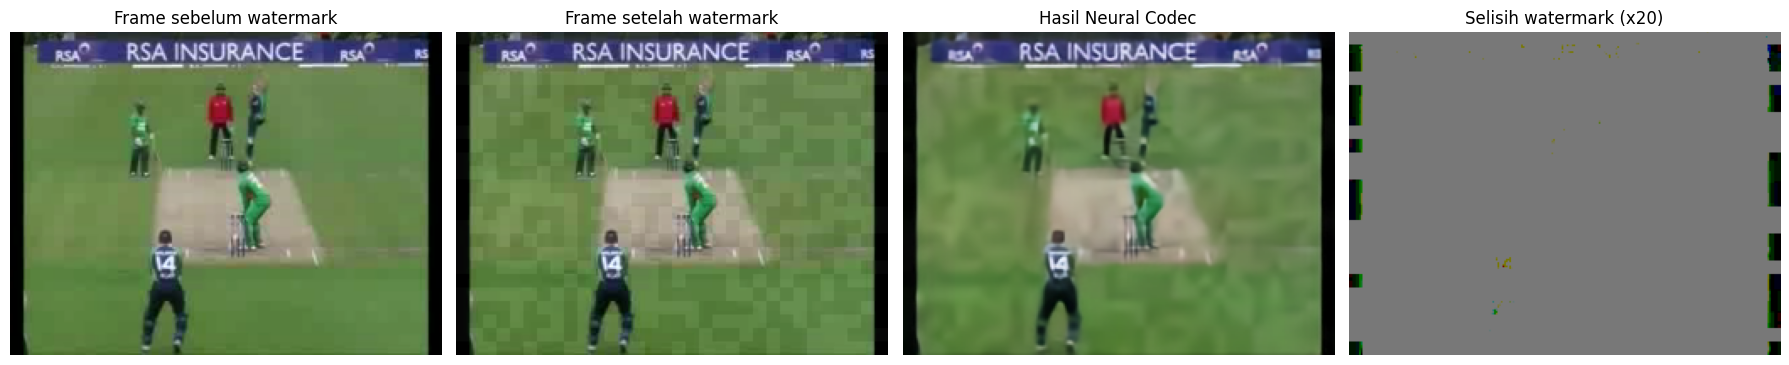

In [29]:
fmt = {'BER': '{:.4f}', 'Bit Accuracy': '{:.4f}', 'PSNR_WM (dB)': '{:.2f}', 'PSNR_Codec (dB)': '{:.2f}', 'bpp': '{:.3f}'}
cols = ['Video', 'BER', 'Bit Accuracy', 'PSNR_WM (dB)', 'PSNR_Codec (dB)', 'Teks Terbaca', 'Status Deteksi']
print('=== Video ber-watermark -> Neural Codec -> baca pixel ===')
display(df_wm[cols].style.format(fmt))
print(f"Rata-rata: BER={df_wm.BER.mean():.4f} | Bit Accuracy={df_wm['Bit Accuracy'].mean():.4f} | "
      f"PSNR_WM={df_wm['PSNR_WM (dB)'].mean():.2f} dB | terdeteksi {(df_wm['Status Deteksi'] == 'Terdeteksi').sum()}/{len(df_wm)} video")

print('\n=== False positive: video TANPA watermark -> Neural Codec -> baca pixel ===')
display(df_fp[['Video', 'BER', 'Bit Accuracy', 'Teks Terbaca', 'Status Deteksi']].style.format(fmt))

df_wm.to_csv(f'{OUTPUT_DIR}/hasil_watermark_pixel.csv', index=False)
df_fp.to_csv(f'{OUTPUT_DIR}/hasil_false_positive.csv', index=False)

# ---- ringkasan visual untuk satu video ----
v = next(iter(videos)); i = 0
orig, wm, comp = videos[v][0][i], wm_videos[v][i], codec_wm[v][i]
print(f'\nVideo contoh: {v}')
print(f'Watermark asli     : "{PAYLOAD_TEXT}"')
print(f'Payload asli       : {bits_str(PAYLOAD)}')
print(f'Payload terbaca    : {bits_str(read_bits[v])}  -> "{bits_to_text(read_bits[v])}"')
fig, ax = plt.subplots(1, 4, figsize=(18, 3.6))
for a, im, t in zip(ax, [orig, wm, comp, np.clip(np.abs(wm.astype(int) - orig) * 20, 0, 255).astype(np.uint8)],
                    ['Frame sebelum watermark', 'Frame setelah watermark', 'Hasil Neural Codec', 'Selisih watermark (x20)']):
    a.imshow(im); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

## 17. (Opsional) Pilih `STRENGTH`

Menjalankan alur yang sama untuk beberapa nilai `STRENGTH` pada satu video, supaya terlihat trade-off ketahanan (BER) vs perubahan kualitas (PSNR).
Setelah memilih nilai, ubah `STRENGTH` di Bagian 2 lalu jalankan ulang dari Bagian 8.

In [30]:
v0 = next(iter(videos)); f0 = videos[v0][0]
rows_s = []
for s in [2, 4, 6, 8, 12, 16]:
    wm_s = embed_pixel_watermark(f0, PAYLOAD, strength=s)
    comp_s, _ = neural_codec(wm_s)
    r = evaluate(extract_pixel_watermark(comp_s))
    rows_s.append({'STRENGTH': s, 'PSNR_WM (dB)': psnr(wm_s, f0), 'BER': r['BER'], 'Bit Accuracy': r['Bit Accuracy'], 'Status Deteksi': r['Status Deteksi']})
display(pd.DataFrame(rows_s).style.format({'PSNR_WM (dB)': '{:.2f}', 'BER': '{:.4f}', 'Bit Accuracy': '{:.4f}'}))

,STRENGTH,PSNR_WM (dB),BER,Bit Accuracy,Status Deteksi
0,2,42.22,0.0625,0.9375,Terdeteksi
1,4,36.21,0.0208,0.9792,Terdeteksi
2,6,32.70,0.0000,1.0000,Terdeteksi
3,8,30.20,0.0000,1.0000,Terdeteksi
4,12,26.68,0.0000,1.0000,Terdeteksi
5,16,24.19,0.0000,1.0000,Terdeteksi


## 18. Visualisasi & Validasi Lokasi Watermark (tambahan; pipeline utama tidak diubah)

Cell di bawah ini **hanya membaca** `videos` dan `wm_videos` yang sudah ada. Tidak ada data yang diubah, dan `embed_pixel_watermark`, `extract_pixel_watermark`, codec, serta metrik tetap seperti semula.

- Urutan payload: blok **row-major** `b0 -> b47` (kiri ke kanan, lalu turun baris), 1 blok = 1 bit, di **setiap frame**.
- Pola modulasi ±1 boleh berbeda tiap frame; yang tetap hanyalah **urutan bit** dan **posisi blok**.
- Validasi memakai rekonstruksi independen: tiap blok `b_i` ditempel satu per satu di kotaknya, lalu hasilnya dibandingkan **piksel demi piksel** dengan keluaran `embed_pixel_watermark`.

In [31]:
def block_boxes(H, W, grid=GRID):
    '''Kotak (y0, y1, x0, x1) tiap blok, urutan row-major b0..b47 (i = baris*kolom + kolom).
    Rumus ukuran blok sama dengan embed_pixel_watermark: bh = H // R, bw = W // C.'''
    R, C = grid; bh, bw = H // R, W // C
    return [(r * bh, (r + 1) * bh, c * bw, (c + 1) * bw) for r in range(R) for c in range(C)]


def _expected_wm(orig, bits=PAYLOAD, strength=STRENGTH):
    '''Rekonstruksi independen: tempel blok b_i satu per satu di kotaknya (tanpa trik reshape).'''
    T, H, W, _ = orig.shape
    pats = make_patterns(T, H, W)                                    # pola ±1 yang sama dengan embedding
    delta = np.zeros((T, H, W), np.float32)
    for i, (y0, y1, x0, x1) in enumerate(block_boxes(H, W)):
        delta[:, y0:y1, x0:x1] = strength * (2 * int(bits[i]) - 1) * pats[:, i]
    return np.clip(np.rint(orig.astype(np.float32) + delta[..., None]), 0, 255).astype(np.uint8), pats


def _draw_grid(ax, boxes, labels, ec='yellow', fs=7):
    for i, (y0, y1, x0, x1) in enumerate(boxes):
        ax.add_patch(plt.Rectangle((x0 - .5, y0 - .5), x1 - x0, y1 - y0, fill=False, ec=ec, lw=1))
        ax.text((x0 + x1) / 2 - .5, (y0 + y1) / 2 - .5, labels[i], ha='center', va='center', fontsize=fs,
                bbox=dict(fc='white', alpha=.75, pad=1, ec='none'))


def visualize_watermark_location(orig, wm, frame_idx=0, bits=PAYLOAD, name=''):
    '''Tampilkan lokasi & urutan bit watermark pada satu frame.
    orig, wm: (T,H,W,3) uint8 = videos[v][0] dan wm_videos[v]. Data asli tidak diubah.'''
    T, H, W, _ = orig.shape; R, C = GRID
    boxes = block_boxes(H, W)
    o, w = orig[frame_idx], wm[frame_idx]
    diff = w.astype(np.float32).mean(-1) - o.astype(np.float32).mean(-1)     # selisih nyata (hanya untuk tampilan)
    m = max(float(np.abs(diff).max()), 1.0)
    lab_bit = [f'{i}:{int(bits[i])}' for i in range(len(bits))]
    lab_ord = [f'b{i}\n={int(bits[i])}' for i in range(len(bits))]

    fig, ax = plt.subplots(2, 2, figsize=(15, 11))
    ax[0, 0].imshow(o);  ax[0, 0].set_title(f'Frame Asli (frame {frame_idx})')
    ax[0, 1].imshow(w);  _draw_grid(ax[0, 1], boxes, lab_bit)
    ax[0, 1].set_title(f'Frame Setelah Watermark (frame {frame_idx}) | label = "nomor blok:bit"')
    im = ax[1, 0].imshow(diff, cmap='seismic', vmin=-m, vmax=m); _draw_grid(ax[1, 0], boxes, lab_bit, ec='black')
    ax[1, 0].set_title(f'Perubahan pixel (watermark - asli), skala ±{m:.0f} level | merah = +, biru = -')
    plt.colorbar(im, ax=ax[1, 0], fraction=0.046, pad=0.02)
    ax[1, 1].imshow(np.asarray(bits).reshape(R, C), cmap='Greens', vmin=0, vmax=1.6)
    for i in range(len(bits)):
        ax[1, 1].text(i % C, i // C, lab_ord[i], ha='center', va='center', fontsize=9)
    ax[1, 1].set_xticks(range(C)); ax[1, 1].set_yticks(range(R))
    ax[1, 1].set_title('Urutan blok row-major: b0 -> b47 (hijau tua = bit 1)')
    for a in ax.ravel()[:3]: a.axis('off')
    fig.suptitle(f'{name} | payload "{PAYLOAD_TEXT}" | grid {R} x {C}', fontsize=13)
    plt.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()


def check_watermark(orig, wm, bits=PAYLOAD, strength=STRENGTH, show_frames=5, verbose=True):
    '''Validasi otomatis: lokasi, urutan, payload, dan keberadaan watermark di SETIAP frame.'''
    T, H, W, _ = orig.shape; R, C = GRID; n = len(bits)
    exp, pats = _expected_wm(orig, bits, strength)
    same = (exp == wm).reshape(T, -1).all(1)                       # (T,) hasil embedding == tempel b0..b47 row-major
    dg = wm.astype(np.float32).mean(-1) - orig.astype(np.float32).mean(-1)     # perubahan nyata yang tertanam
    boxes = block_boxes(H, W)
    corr = np.stack([(dg[:, y0:y1, x0:x1] * pats[:, i]).mean((1, 2)) for i, (y0, y1, x0, x1) in enumerate(boxes)], 1)
    energy = np.stack([np.abs(dg[:, y0:y1, x0:x1]).mean((1, 2)) for (y0, y1, x0, x1) in boxes], 1)
    planted = (corr > 0).astype(int)                                # bit yang benar-benar tertanam di blok b_i, frame t
    ok_bits  = (planted == np.asarray(bits)[None]).all(1)           # payload tiap frame = "sabila", urutan b0 -> b47
    ok_block = (energy > 0).all(1)                                  # 48 blok di tiap frame benar-benar berubah
    checks = {
        'Setiap frame punya 48 blok'      : len(boxes) == R * C == n,
        'Posisi blok sama di tiap frame'  : bool(same.all()),
        'Urutan bit b0 -> b47 (row-major)': bool(ok_bits.all()),
        'Payload tiap frame = payload asli': bool(ok_bits.all()),
        'Tidak ada frame terlewat'        : bool(ok_block.all()) and len(wm) == len(orig),
        'Total bit ditanam = frame x 48'  : int((planted == np.asarray(bits)[None]).sum()) == T * n,
    }
    if verbose:
        print('[CHECK WATERMARK]')
        print(f'Jumlah frame       : {T}')
        print(f'Payload            : {PAYLOAD_TEXT}')
        print(f'Payload length     : {n} bit')
        print(f'Grid               : {R} × {C}')
        print(f'Watermark/frame    : {n} bit')
        print(f'Total bit ditanam  : {int((planted == np.asarray(bits)[None]).sum())} bit (harapan {T * n})')
        print(f'Urutan             : b0 → b{n - 1} ({"OK" if checks["Urutan bit b0 -> b47 (row-major)"] else "GAGAL"})')
        print(f'Semua frame        : {"OK" if checks["Tidak ada frame terlewat"] and same.all() else "GAGAL"}')
        for t in range(min(show_frames, T)):
            print(f'Frame {t} → watermark {int((planted[t] == np.asarray(bits)).sum())} bit' + ('' if ok_bits[t] and same[t] else '  <-- TIDAK SESUAI'))
        if T > show_frames:
            print('...')
            print(f'Frame {T - 1} → watermark {int((planted[T - 1] == np.asarray(bits)).sum())} bit' + ('' if ok_bits[T - 1] and same[T - 1] else '  <-- TIDAK SESUAI'))
        print('Rincian:')
        for k, ok in checks.items():
            print(f'  [{"OK" if ok else "GAGAL"}] {k}')
    return checks, same, ok_bits

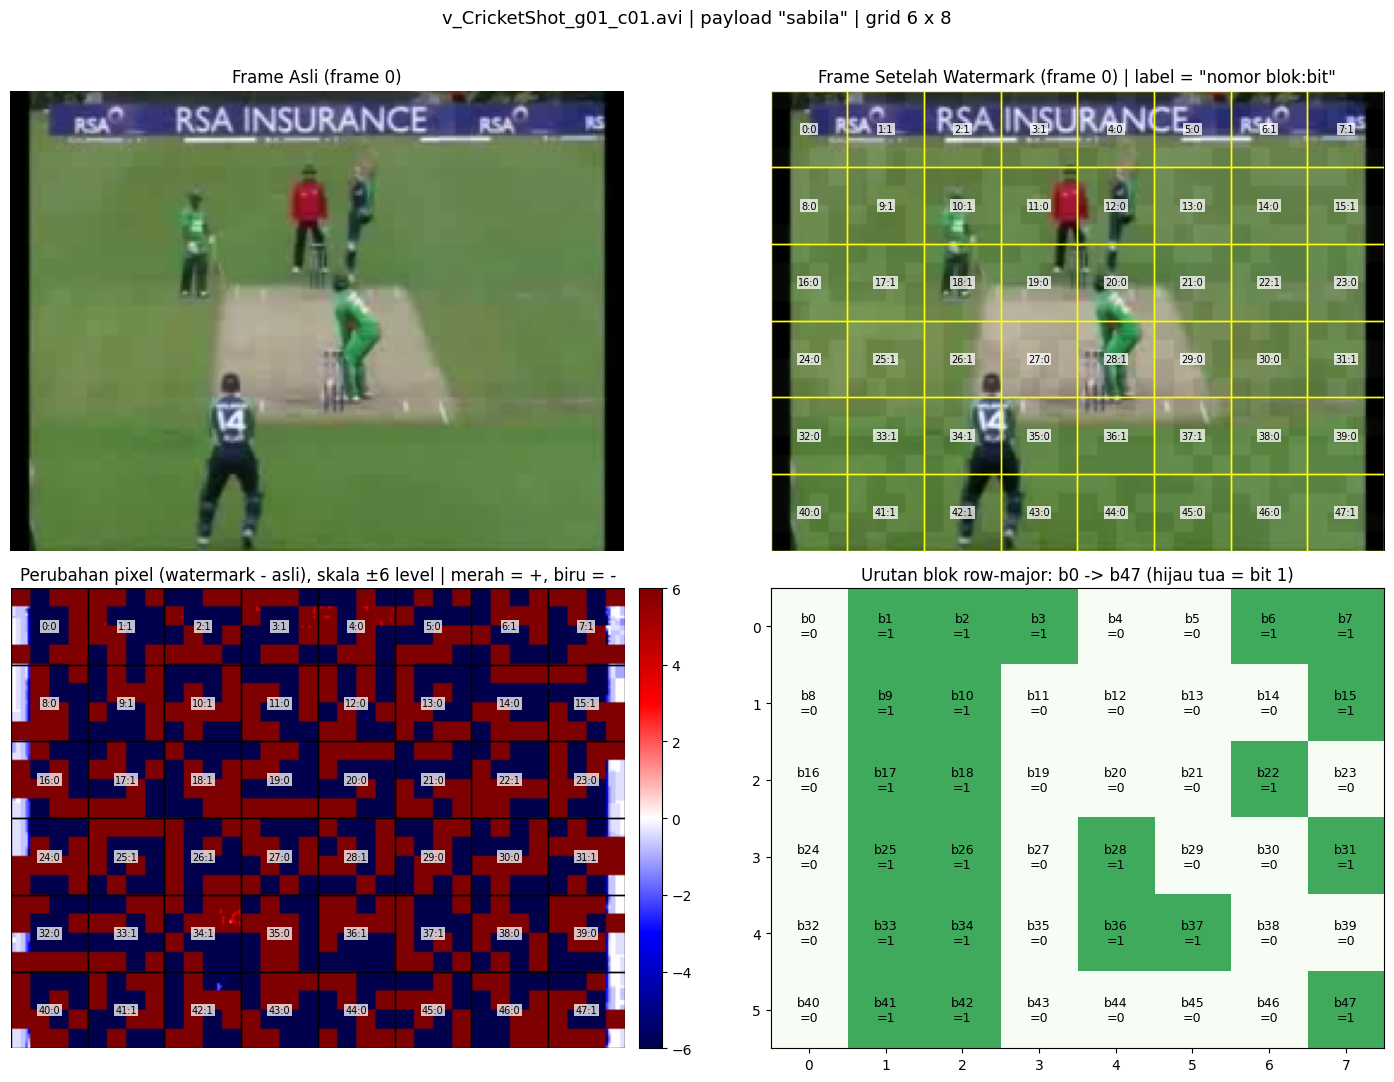

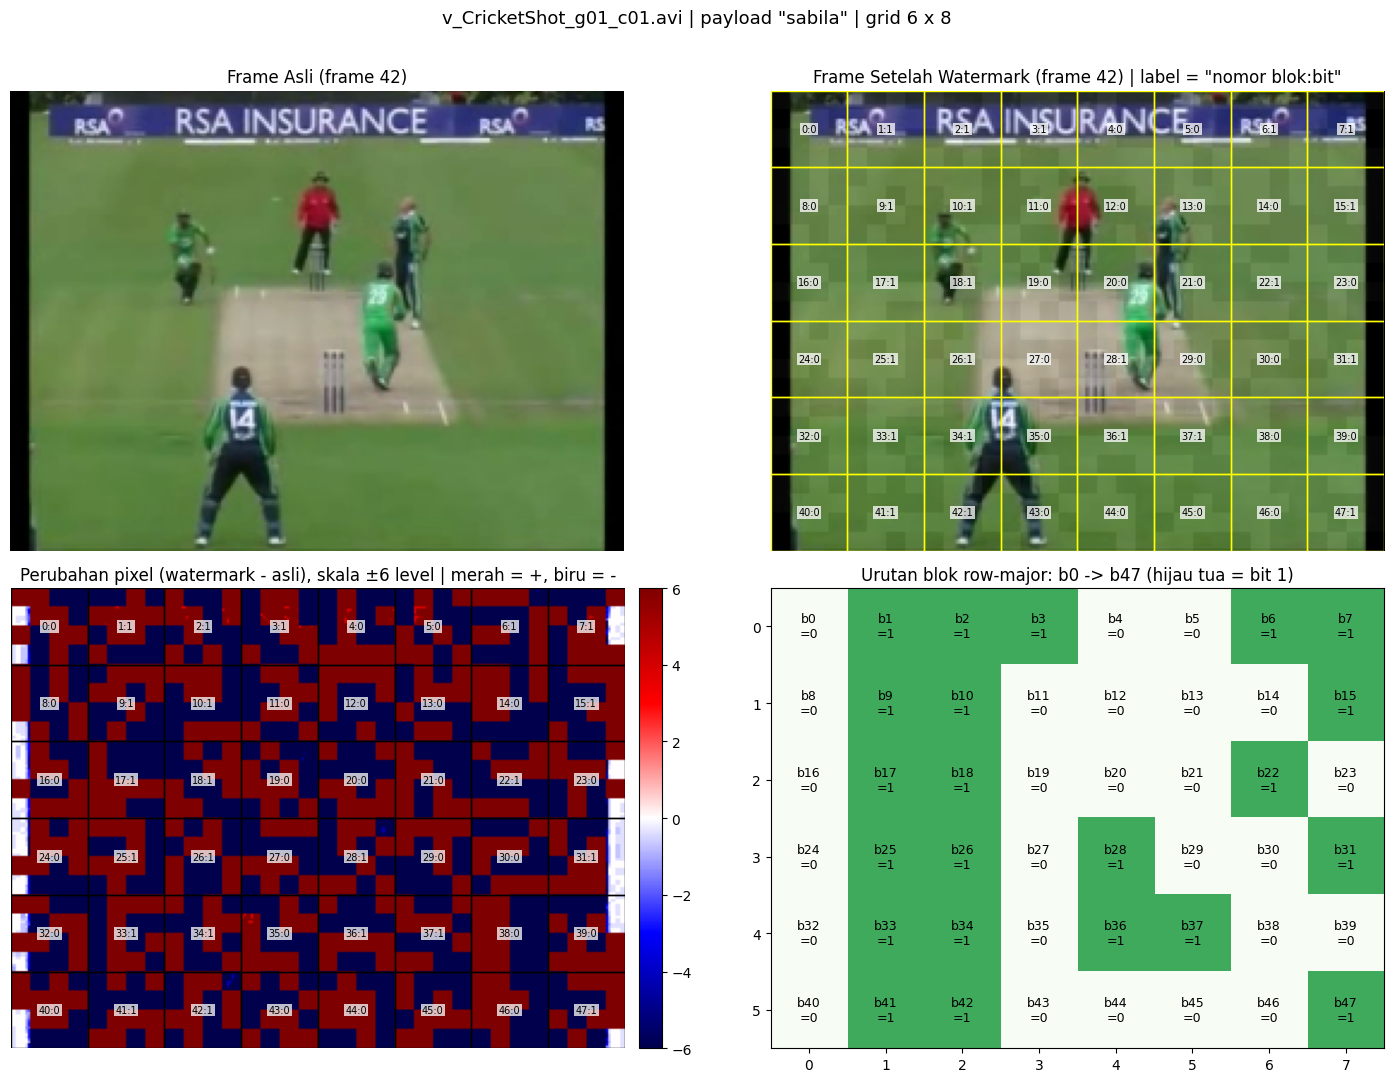

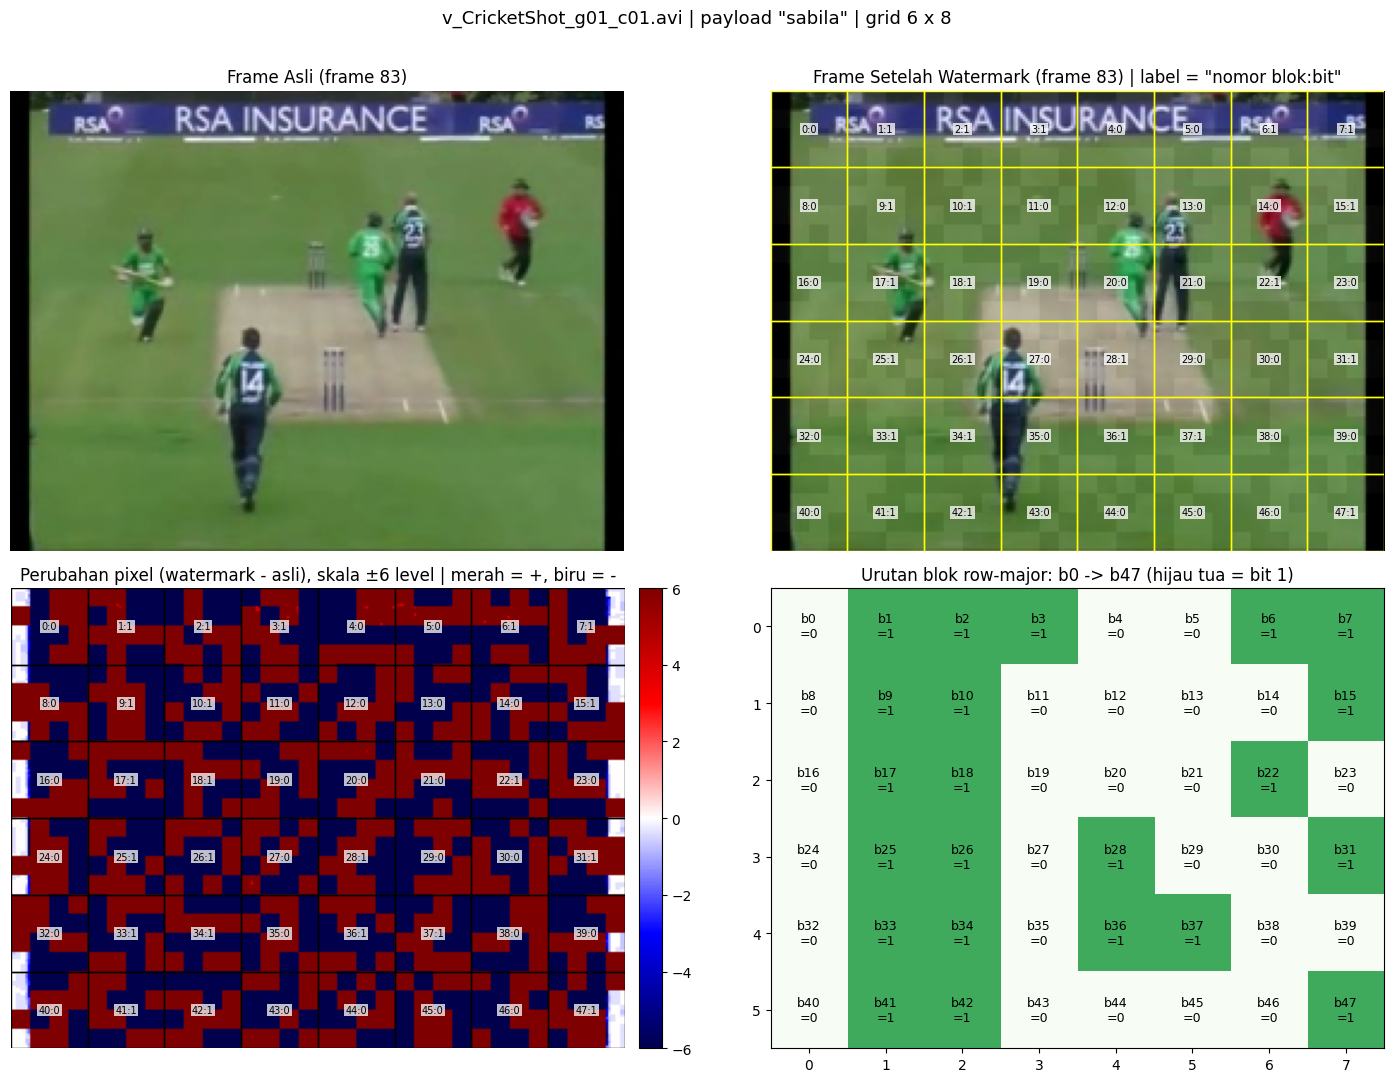

In [32]:
v = next(iter(videos))                     # ganti dengan nama video lain bila perlu
orig_v, wm_v = videos[v][0], wm_videos[v]
T = len(orig_v)
for t in [0, T // 2, T - 1]:               # frame awal, tengah, akhir: lokasi & urutan harus identik
    visualize_watermark_location(orig_v, wm_v, frame_idx=t, name=v)

In [33]:
checks, same, ok_bits = check_watermark(videos[v][0], wm_videos[v])
assert all(checks.values()), 'Ada ketidaksesuaian lokasi/urutan/payload watermark!'

# --- ringkasan seluruh video ---
rows_chk = []
for name, (fr, _) in videos.items():
    c, s, ob = check_watermark(fr, wm_videos[name], verbose=False)
    rows_chk.append({'Video': name, 'Jumlah frame': len(fr), 'Total bit ditanam': len(fr) * N_BITS,
                     'Frame OK': int((s & ob).sum()), 'Urutan b0-b47': 'OK' if c['Urutan bit b0 -> b47 (row-major)'] else 'GAGAL',
                     'Semua frame': 'OK' if all(c.values()) else 'GAGAL'})
df_chk = pd.DataFrame(rows_chk)
display(df_chk)
print(f"Semua video lolos validasi: {(df_chk['Semua frame'] == 'OK').all()} ({(df_chk['Semua frame'] == 'OK').sum()}/{len(df_chk)})")

[CHECK WATERMARK]
Jumlah frame       : 84
Payload            : sabila
Payload length     : 48 bit
Grid               : 6 × 8
Watermark/frame    : 48 bit
Total bit ditanam  : 4032 bit (harapan 4032)
Urutan             : b0 → b47 (OK)
Semua frame        : OK
Frame 0 → watermark 48 bit
Frame 1 → watermark 48 bit
Frame 2 → watermark 48 bit
Frame 3 → watermark 48 bit
Frame 4 → watermark 48 bit
...
Frame 83 → watermark 48 bit
Rincian:
  [OK] Setiap frame punya 48 blok
  [OK] Posisi blok sama di tiap frame
  [OK] Urutan bit b0 -> b47 (row-major)
  [OK] Payload tiap frame = payload asli
  [OK] Tidak ada frame terlewat
  [OK] Total bit ditanam = frame x 48


,Video,Jumlah frame,Total bit ditanam,Frame OK,Urutan b0-b47,Semua frame
0,v_CricketShot_g01_c01.avi,84,4032,84,OK,OK
1,v_CricketShot_g01_c02.avi,91,4368,91,OK,OK
2,v_CricketShot_g01_c03.avi,95,4560,95,OK,OK
3,v_CricketShot_g01_c04.avi,72,3456,72,OK,OK
4,v_CricketShot_g01_c05.avi,95,4560,95,OK,OK
5,v_CricketShot_g01_c06.avi,76,3648,76,OK,OK
6,v_CricketShot_g01_c07.avi,71,3408,71,OK,OK
7,v_CricketShot_g02_c01.avi,100,4800,100,OK,OK
8,v_CricketShot_g02_c02.avi,93,4464,93,OK,OK
9,v_CricketShot_g02_c03.avi,97,4656,97,OK,OK


Semua video lolos validasi: True (30/30)
